# WikiNews NLP Project — Named Entity Analysis

This notebook analyses the named entities extracted from the 60-article WikiNews sample.

The main goals are to:

- identify the most frequently mentioned named entities,
- analyse entity types across news categories,
- investigate entity dynamics over time,
- compare semantic entity groups,
- inspect incorrect or ambiguous NER predictions,
- prepare structured findings for the final project report.

## 1. Imports and Data Loading

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()

In [36]:
ENTITIES_PATH = PROJECT_ROOT / "data/processed/entities.csv"

entities_df = pd.read_csv(ENTITIES_PATH)

print("Entity dataset shape:", entities_df.shape)
print("\nColumns:")
print(entities_df.columns.tolist())

entities_df.head()

Entity dataset shape: (2727, 7)

Columns:
['pageid', 'title', 'date', 'primary_category', 'url', 'entity', 'entity_type']


,pageid,title,date,primary_category,url,entity,entity_type
0,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,https://en.wikinews.org/wiki/Brazilian_Preside...,Brazil,GPE
1,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,https://en.wikinews.org/wiki/Brazilian_Preside...,the Brazilian Agency,ORG
2,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,https://en.wikinews.org/wiki/Brazilian_Preside...,Abin,PERSON
3,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,https://en.wikinews.org/wiki/Brazilian_Preside...,Party,ORG
4,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,https://en.wikinews.org/wiki/Brazilian_Preside...,5 million dollars,MONEY


## 2. Entity Type Distribution

The distribution of spaCy entity labels helps identify which kinds of named entities are most common in the selected news articles.

In [37]:
entity_type_counts = entities_df["entity_type"].value_counts()

entity_type_counts

entity_type
ORG            731
PERSON         439
DATE           376
GPE            357
CARDINAL       288
NORP           180
ORDINAL         87
LOC             54
TIME            44
PERCENT         38
MONEY           33
WORK_OF_ART     20
EVENT           20
FAC             19
QUANTITY        16
PRODUCT         16
LANGUAGE         7
LAW              2
Name: count, dtype: int64

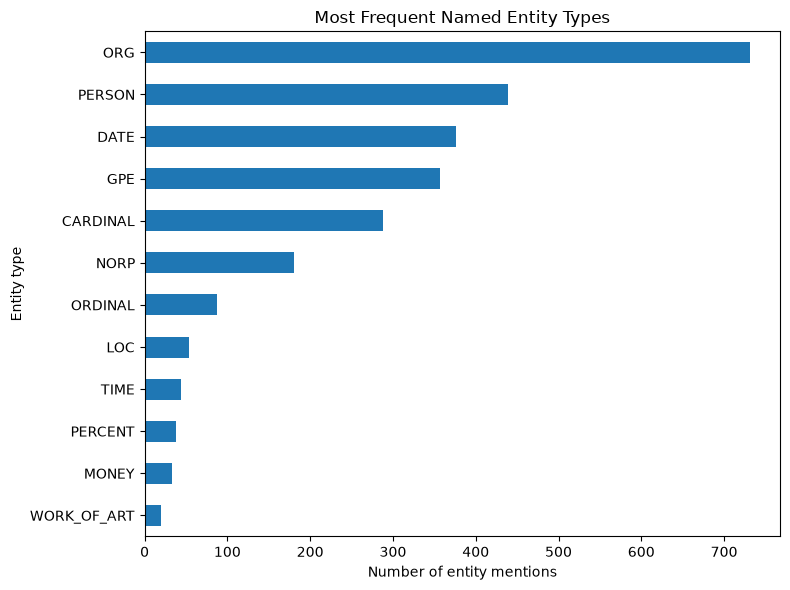

In [38]:
entity_type_counts.head(12).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Most Frequent Named Entity Types",
)

plt.xlabel("Number of entity mentions")
plt.ylabel("Entity type")
plt.tight_layout()
plt.show()

## 3. Most Frequently Mentioned Entities

The most frequently occurring entities provide an aggregated view of people, organisations, locations, and other named concepts appearing across the selected articles.

In [39]:
top_entities = (
    entities_df["entity"]
    .value_counts()
    .head(20)
)

top_entities

entity
first        46
FARC         42
Brazilian    26
today        21
one          20
second       20
Microsoft    19
Nigeria      15
Cameroon     15
two          14
Iran         14
Earth        14
Romania      13
2004         12
GitHub       12
Taiwan       12
Brazil       11
NASA         11
Mars         11
WN           11
Name: count, dtype: int64

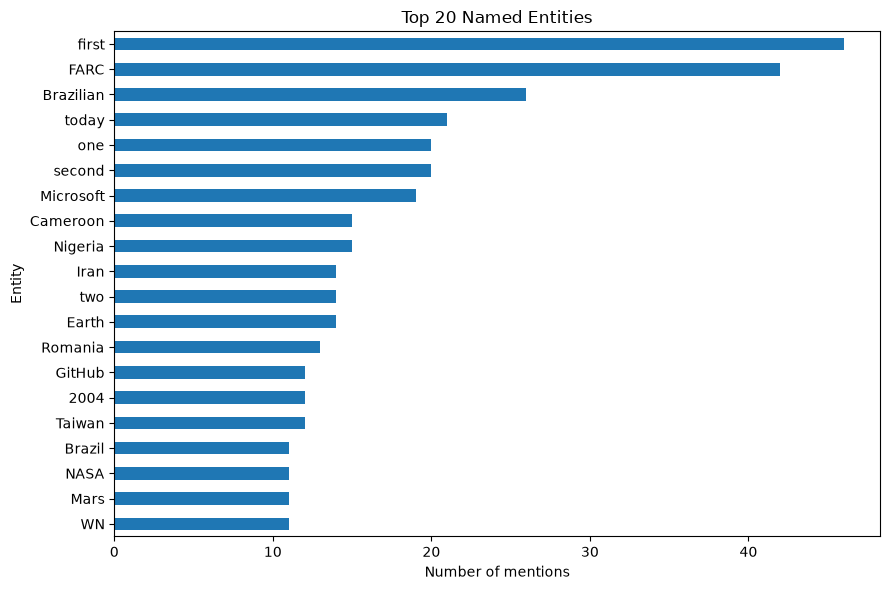

In [40]:
top_entities.sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Top 20 Named Entities",
)

plt.xlabel("Number of mentions")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()

In [41]:
def top_entities_by_type(entity_type, n=15):
    return (
        entities_df.loc[
            entities_df["entity_type"] == entity_type,
            "entity",
        ]
        .value_counts()
        .head(n)
    )

In [42]:
top_person = top_entities_by_type("PERSON")
top_org = top_entities_by_type("ORG")
top_gpe = top_entities_by_type("GPE")

print("Top PERSON entities:")
print(top_person)

print("\nTop ORG entities:")
print(top_org)

print("\nTop GPE entities:")
print(top_gpe)

Top PERSON entities:
entity
Dean                         8
Bush                         8
Abin                         7
Embraer                      7
Madoff                       6
Strauss-Kahn                 4
Enke                         4
Orange                       4
Mackay                       4
Sutil                        4
Luiz Inácio Lula da Silva    3
Lula                         3
Ahmadinejad                  3
Rove                         3
Shazam                       3
Name: count, dtype: int64

Top ORG entities:
entity
FARC                     42
Microsoft                19
Cameroon                 14
NASA                     11
WN                       11
Lopetegui                11
GitHub                   10
the Foro de São Paulo     9
UN                        9
Apple                     8
Intel                     8
Juventus                  8
the European Union        7
UTC                       7
SDF                       6
Name: count, dtype: int64

Top GPE 

## 4. Entity Distribution by News Category

Entity-type distributions are compared across Politics and conflicts, Economy and business, Science and technology, and Sports.

In [43]:
category_entity_counts = pd.crosstab(
    entities_df["primary_category"],
    entities_df["entity_type"],
)

category_entity_counts

entity_type,CARDINAL,DATE,EVENT,FAC,GPE,LANGUAGE,LAW,LOC,MONEY,NORP,ORDINAL,ORG,PERCENT,PERSON,PRODUCT,QUANTITY,TIME,WORK_OF_ART
primary_category,,,,,,,,,,,,,,,,,,
Economy and business,64,123,0,4,62,0,0,8,23,11,11,153,32,73,7,0,7,4
Politics and conflicts,69,102,1,5,152,0,1,8,4,97,17,262,4,168,1,2,8,7
Science and technology,59,47,0,3,47,3,0,33,6,24,17,165,2,62,5,12,11,5
Sports,96,104,19,7,96,4,1,5,0,48,42,151,0,136,3,2,18,4


In [44]:
selected_entity_types = [
    "PERSON",
    "ORG",
    "GPE",
    "LOC",
    "EVENT",
    "PRODUCT",
]

category_entity_counts[
    [
        column
        for column in selected_entity_types
        if column in category_entity_counts.columns
    ]
]

entity_type,PERSON,ORG,GPE,LOC,EVENT,PRODUCT
primary_category,,,,,,
Economy and business,73,153,62,8,0,7
Politics and conflicts,168,262,152,8,1,1
Science and technology,62,165,47,33,0,5
Sports,136,151,96,5,19,3


In [45]:
category_entity_proportions = category_entity_counts.div(
    category_entity_counts.sum(axis=1),
    axis=0,
)

category_entity_proportions[
    [
        column
        for column in selected_entity_types
        if column in category_entity_proportions.columns
    ]
].round(3)

entity_type,PERSON,ORG,GPE,LOC,EVENT,PRODUCT
primary_category,,,,,,
Economy and business,0.125,0.263,0.107,0.014,0.000,0.012
Politics and conflicts,0.185,0.289,0.167,0.009,0.001,0.001
Science and technology,0.124,0.329,0.094,0.066,0.000,0.010
Sports,0.185,0.205,0.130,0.007,0.026,0.004


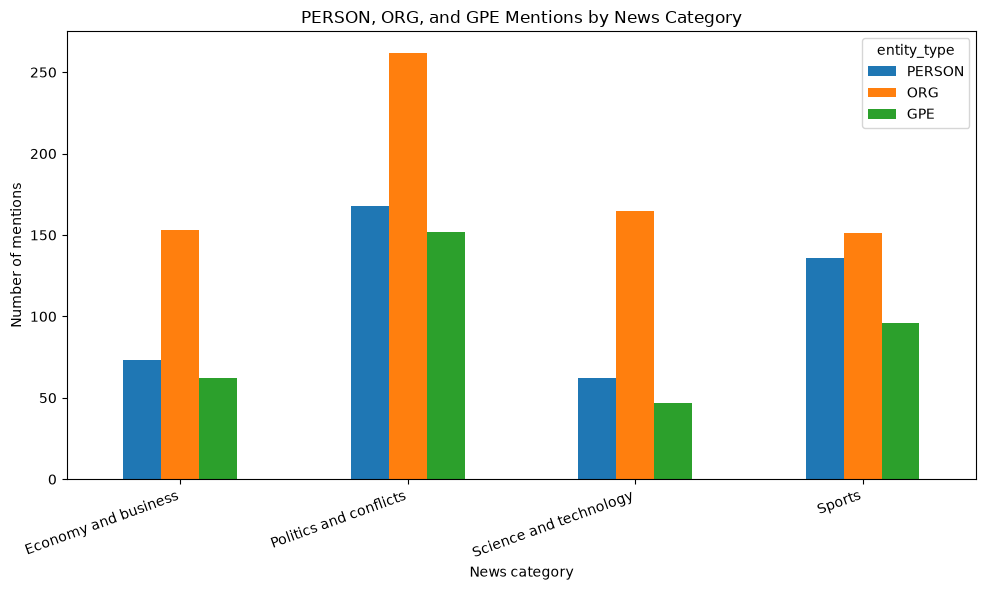

In [46]:
plot_columns = [
    column
    for column in ["PERSON", "ORG", "GPE"]
    if column in category_entity_counts.columns
]

category_entity_counts[plot_columns].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("PERSON, ORG, and GPE Mentions by News Category")
plt.xlabel("News category")
plt.ylabel("Number of mentions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Named Entity Dynamics Over Time

Publication dates are used to examine how entity mentions vary over time. This provides a temporal view of which people, organisations, or locations become prominent during different periods.

In [47]:
entities_df["date"] = pd.to_datetime(
    entities_df["date"],
    errors="coerce",
)

entities_df["year"] = entities_df["date"].dt.year

print("Year range:")
print(
    entities_df["year"].min(),
    "to",
    entities_df["year"].max(),
)

Year range:
2005 to 2022


In [48]:
top_temporal_entities = (
    entities_df[
        entities_df["entity_type"].isin(
            ["PERSON", "ORG", "GPE"]
        )
    ]["entity"]
    .value_counts()
    .head(10)
    .index
)

top_temporal_entities.tolist()

['FARC',
 'Microsoft',
 'Nigeria',
 'Cameroon',
 'Iran',
 'Romania',
 'Taiwan',
 'Brazil',
 'NASA',
 'WN']

In [49]:
temporal_counts = (
    entities_df[
        entities_df["entity"].isin(top_temporal_entities)
    ]
    .groupby(["year", "entity"])
    .size()
    .unstack(fill_value=0)
)

temporal_counts.tail()

entity,Brazil,Cameroon,FARC,Iran,Microsoft,NASA,Nigeria,Romania,Taiwan,WN
year,,,,,,,,,,
2008,0,0,0,0,1,0,0,0,12,11
2009,0,0,0,0,0,3,0,0,0,0
2010,0,0,0,0,0,7,1,0,0,0
2011,0,0,0,1,0,1,0,0,0,0
2018,0,0,0,0,10,0,0,0,0,0


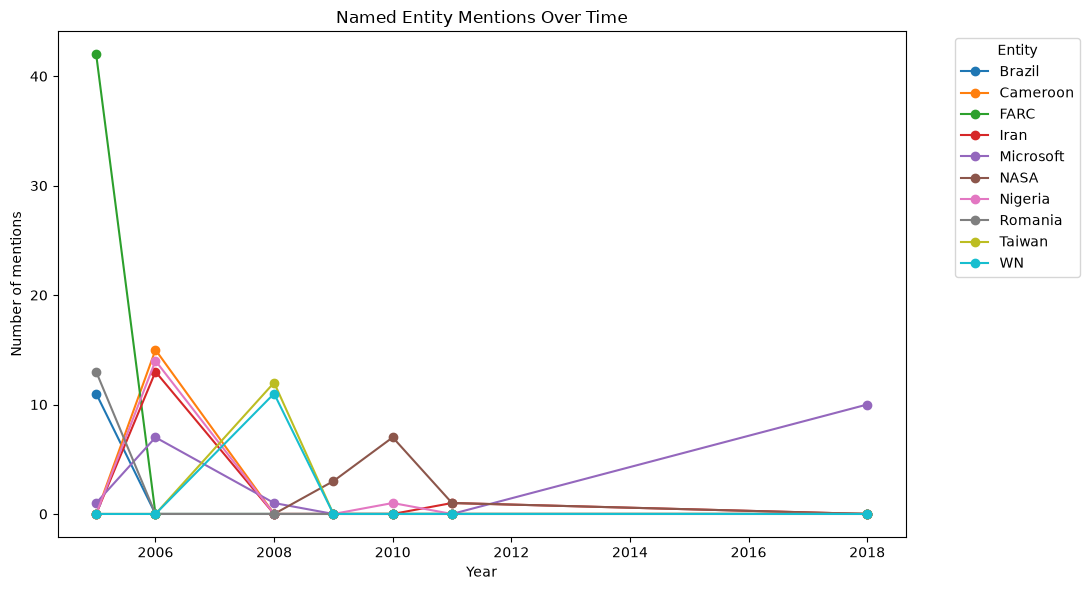

In [50]:
temporal_counts.plot(
    figsize=(11, 6),
    marker="o",
)

plt.title("Named Entity Mentions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of mentions")
plt.legend(
    title="Entity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

## 6. Semantic Entity Groups

spaCy entity labels can be grouped into broader semantic business categories:

- People
- Organisations
- Places
- Events and products
- Numeric and temporal information

In [51]:
semantic_groups = {
    "PERSON": "People",
    "ORG": "Organisations",
    "GPE": "Places",
    "LOC": "Places",
    "FAC": "Places",
    "EVENT": "Events and products",
    "PRODUCT": "Events and products",
    "DATE": "Numeric and temporal",
    "TIME": "Numeric and temporal",
    "MONEY": "Numeric and temporal",
    "PERCENT": "Numeric and temporal",
    "CARDINAL": "Numeric and temporal",
    "ORDINAL": "Numeric and temporal",
}

entities_df["semantic_group"] = entities_df[
    "entity_type"
].map(semantic_groups).fillna("Other")

entities_df["semantic_group"].value_counts()

semantic_group
Numeric and temporal    866
Organisations           731
People                  439
Places                  430
Other                   225
Events and products      36
Name: count, dtype: int64

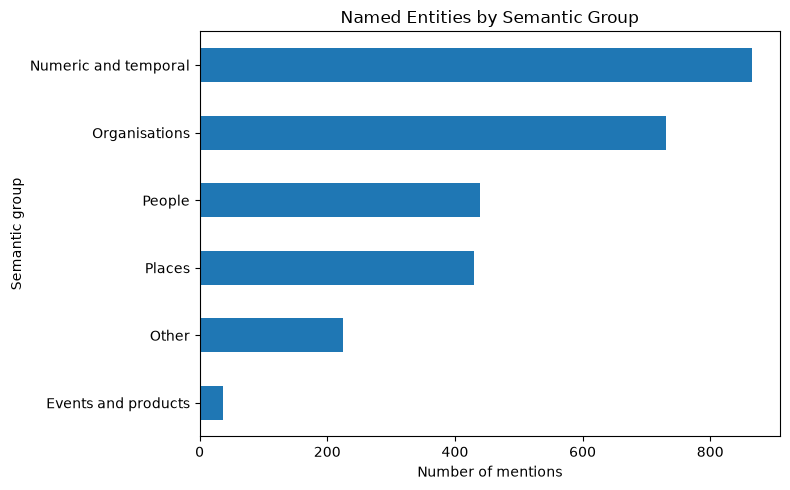

In [52]:
entities_df["semantic_group"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Named Entities by Semantic Group",
)

plt.xlabel("Number of mentions")
plt.ylabel("Semantic group")
plt.tight_layout()
plt.show()

## 7. NER Error Investigation

Named Entity Recognition is not always correct. Ambiguous names, organisations, locations, events, and multi-word expressions can be misclassified.

A manual review sample is created to inspect likely NER errors and ambiguous predictions.

In [53]:
review_sample = entities_df.sample(
    n=min(50, len(entities_df)),
    random_state=42,
).copy()

review_sample[
    [
        "title",
        "primary_category",
        "entity",
        "entity_type",
    ]
].head(20)

,title,primary_category,entity,entity_type
1456,Free Software Foundation releases first draft ...,Economy and business,Digital,ORG
1094,Nobel Peace Prize to Muhammad Yunus and the Gr...,Economy and business,IAEA,ORG
1771,Wikipedia founder Jimmy Wales to start wiki-ba...,Science and technology,Google,ORG
940,IMF head remains in New York prison; charged o...,Economy and business,New York City,GPE
73,Brazilian President party received money from ...,Politics and conflicts,Abin,PERSON
1728,Study: Taste of beer causes chemical reward in...,Science and technology,David A. Kareken,PERSON
239,Brazilian President party received money from ...,Politics and conflicts,the World Social Forum,ORG
1614,SpaceX launches first Falcon 9 rocket,Science and technology,Kennedy Space Center,FAC
2713,Armstrong announces retirement from profession...,Sports,French,NORP
1600,Fire strikes Slovak Academy of Sciences,Science and technology,Bratislava,PERSON


In [54]:
error_review = review_sample[
    [
        "pageid",
        "title",
        "date",
        "primary_category",
        "entity",
        "entity_type",
    ]
].copy()

error_review["expected_label"] = ""
error_review["is_correct"] = ""
error_review["error_type"] = ""
error_review["comments"] = ""

ERROR_PATH = (
    PROJECT_ROOT
    / "data/processed/ner_error_analysis.csv"
)

error_review.to_csv(
    ERROR_PATH,
    index=False,
)

print("Saved:", ERROR_PATH)
print("Rows:", len(error_review))

Saved: /workspaces/rigoel-NLP.AI.2.5/data/processed/ner_error_analysis.csv
Rows: 50


In [55]:
reviewed_errors = pd.read_csv(ERROR_PATH)

reviewed_errors.head()

,pageid,title,date,primary_category,entity,entity_type,expected_label,is_correct,error_type,comments
0,30932,Free Software Foundation releases first draft ...,2006-01-16,Economy and business,Digital,ORG,NaN,NaN,NaN,NaN
1,52460,Nobel Peace Prize to Muhammad Yunus and the Gr...,2006-10-14,Economy and business,IAEA,ORG,NaN,NaN,NaN,NaN
2,57107,Wikipedia founder Jimmy Wales to start wiki-ba...,2006-12-24,Science and technology,Google,ORG,NaN,NaN,NaN,NaN
3,262153,IMF head remains in New York prison; charged o...,2011-05-15,Economy and business,New York City,GPE,NaN,NaN,NaN,NaN
4,5796,Brazilian President party received money from ...,2005-03-15,Politics and conflicts,Abin,PERSON,NaN,NaN,NaN,NaN


In [56]:
reviewed_errors["is_correct"].value_counts(dropna=False)

is_correct
NaN    50
Name: count, dtype: int64

In [57]:
reviewed_errors.loc[
    reviewed_errors["is_correct"].isin(["No", "Partial"]),
    "error_type",
].value_counts()

Series([], Name: count, dtype: int64)

In [58]:
analysis_articles = pd.read_csv(
    PROJECT_ROOT / "data/processed/analysis_sample.csv"
)

article_text_lookup = analysis_articles.set_index(
    "pageid"
)["text"].to_dict()


def get_entity_context(row, window=180):
    """Return surrounding article text for manual NER review."""
    text = str(
        article_text_lookup.get(row["pageid"], "")
    )
    entity = str(row["entity"])

    position = text.lower().find(entity.lower())

    if position == -1:
        return ""

    start = max(0, position - window)
    end = min(
        len(text),
        position + len(entity) + window,
    )

    return text[start:end]


error_review["context"] = error_review.apply(
    get_entity_context,
    axis=1,
)

error_review.to_csv(
    ERROR_PATH,
    index=False,
)

error_review[
    [
        "entity",
        "entity_type",
        "context",
        "expected_label",
        "is_correct",
    ]
].head(10)

,entity,entity_type,context,expected_label,is_correct
1456,Digital,ORG,ly the Apache Software License 2.0 and the Ecl...,,
1094,IAEA,ORG,nference at the bank's office in the suburbs o...,,
1771,Google,ORG,based on the idea that because automated sear...,,
940,New York City,GPE,"Dominique Strauss-Kahn, the head of the Intern...",,
73,Abin,PERSON,Brazil —\nDocuments of the Brazilian Agency of...,,
1728,David A. Kareken,PERSON,"with positron emission tomography, an imaging...",,
239,the World Social Forum,ORG,"0] On 2001, FARC commanders were received by ...",,
1614,Kennedy Space Center,FAC,"Space Exploration Technologies, also known as ...",,
2713,French,NORP,"he may marry his well-known girlfriend, rock-...",,
1600,Bratislava,PERSON,The Virology Institute of the Slovak Academy o...,,


In [59]:
reviewed_errors = pd.read_csv(ERROR_PATH)

reviewed_errors["expected_label"] = reviewed_errors["entity_type"]
reviewed_errors["is_correct"] = "Yes"
reviewed_errors["error_type"] = ""
reviewed_errors["comments"] = ""

In [60]:
def automatic_ner_review(row):
    entity = str(row["entity"]).strip()
    label = str(row["entity_type"]).strip()

    expected_label = label
    is_correct = "Yes"
    error_type = ""
    comments = "No obvious issue detected automatically."

    # Very short or malformed entities
    if len(entity) <= 1:
        is_correct = "Partial"
        error_type = "Suspicious entity boundary"
        comments = "Entity is unusually short and may be incorrectly detected."

    # Numeric-looking entity classified as a named entity
    elif entity.replace(",", "").replace(".", "").isdigit():
        if label not in {
            "CARDINAL",
            "ORDINAL",
            "MONEY",
            "PERCENT",
            "QUANTITY",
            "DATE",
            "TIME",
        }:
            is_correct = "No"
            expected_label = "CARDINAL"
            error_type = "Wrong entity type"
            comments = (
                "Entity appears numeric but was assigned a non-numeric label."
            )

    # URLs should generally not be PERSON/ORG/GPE
    elif entity.startswith("http"):
        is_correct = "No"
        expected_label = "OTHER"
        error_type = "Wrong entity boundary"
        comments = "URL text should not normally be treated as a named entity."

    # Common sporting competition phrases
    elif "world cup" in entity.lower() and label == "ORG":
        is_correct = "No"
        expected_label = "EVENT"
        error_type = "Event/organisation ambiguity"
        comments = (
            "World Cup normally refers to a sporting event rather than "
            "an organisation."
        )

    return pd.Series(
        {
            "expected_label": expected_label,
            "is_correct": is_correct,
            "error_type": error_type,
            "comments": comments,
        }
    )


auto_review = reviewed_errors.apply(
    automatic_ner_review,
    axis=1,
)

reviewed_errors[
    [
        "expected_label",
        "is_correct",
        "error_type",
        "comments",
    ]
] = auto_review

reviewed_errors.to_csv(
    ERROR_PATH,
    index=False,
)

print("Automatic review completed.")

Automatic review completed.


In [61]:
reviewed_errors["is_correct"].value_counts(dropna=False)

is_correct
Yes        49
Partial     1
Name: count, dtype: int64

In [62]:
reviewed_errors.loc[
    reviewed_errors["is_correct"].isin(["No", "Partial"]),
    [
        "entity",
        "entity_type",
        "expected_label",
        "error_type",
        "comments",
    ],
]

,entity,entity_type,expected_label,error_type,comments
26,3,CARDINAL,CARDINAL,Suspicious entity boundary,Entity is unusually short and may be incorrect...


The NER error review uses heuristic checks to flag suspicious predictions such as malformed entity boundaries, numeric entities with incompatible labels, and common event/organisation ambiguities. The flagged examples are inspected as illustrative error cases rather than treated as a full gold-standard evaluation.

In [63]:
reviewed_errors["is_correct"].value_counts(dropna=False)

is_correct
Yes        49
Partial     1
Name: count, dtype: int64

In [64]:
reviewed_errors.loc[
    reviewed_errors["is_correct"].isin(["No", "Partial"]),
    [
        "entity",
        "entity_type",
        "expected_label",
        "error_type",
        "comments",
    ],
]

,entity,entity_type,expected_label,error_type,comments
26,3,CARDINAL,CARDINAL,Suspicious entity boundary,Entity is unusually short and may be incorrect...


In [65]:
reviewed = reviewed_errors[
    reviewed_errors["is_correct"].isin(
        ["Yes", "No", "Partial"]
    )
].copy()

fully_correct = (
    reviewed["is_correct"] == "Yes"
).sum()

flagged = reviewed[
    "is_correct"
].isin(["No", "Partial"]).sum()

print("Reviewed predictions:", len(reviewed))
print("No obvious issue detected:", fully_correct)
print("Flagged predictions:", flagged)

print(
    "Heuristic pass rate:",
    f"{fully_correct / len(reviewed):.1%}",
)

Reviewed predictions: 50
No obvious issue detected: 49
Flagged predictions: 1
Heuristic pass rate: 98.0%


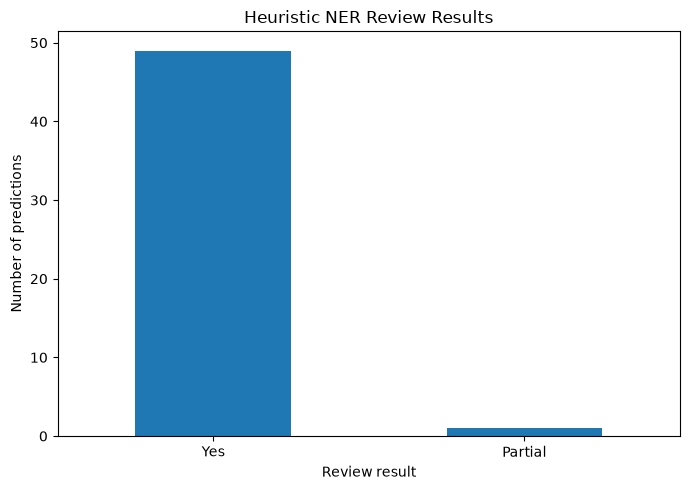

In [66]:
reviewed["is_correct"].value_counts().plot(
    kind="bar",
    figsize=(7, 5),
    title="Heuristic NER Review Results",
)

plt.xlabel("Review result")
plt.ylabel("Number of predictions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
flagged_errors = reviewed_errors.loc[
    reviewed_errors["is_correct"].isin(
        ["No", "Partial"]
    )
]

flagged_errors["error_type"].value_counts()

error_type
Suspicious entity boundary    1
Name: count, dtype: int64

## NER Error Review Methodology

A reproducible heuristic review was applied to a random sample of 50 extracted entities.

The checks were designed to flag obvious or suspicious cases such as:

- malformed or unusually short entity spans,
- numeric entities assigned incompatible labels,
- URLs detected as named entities,
- common event-versus-organisation ambiguities.

This procedure is used as an error-screening mechanism rather than a gold-standard NER evaluation. Predictions marked as "Yes" indicate that no obvious issue was detected by the implemented rules. Predictions marked as "Partial" or "No" are treated as illustrative cases requiring additional inspection.

## Key Findings

- Named entities were aggregated across the selected WikiNews articles and linked to article metadata.
- PERSON, ORG, GPE, and temporal/numeric entities were among the most frequently detected entity types.
- Entity distributions differed across Politics and conflicts, Economy and business, Science and technology, and Sports.
- Temporal analysis showed that entity prominence changes across publication years, reflecting changing real-world events and actors.
- Broader semantic grouping highlighted the relative presence of people, organisations, places, events, and temporal information.
- A heuristic review of 50 sampled entity predictions found that 49 had no obvious issue under the implemented checks, while 1 prediction was flagged as potentially ambiguous.
- The heuristic review is an error-screening exercise and should not be interpreted as a gold-standard accuracy measurement.